In [78]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings(
    "ignore",
    message=".*KMeans is known to have a memory leak on Windows with MKL.*",
    category=UserWarning)    # warning related to OMP_NUM_THREADS are deleted.

In [80]:
## needed library loading
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
import pandas as pd

# loading
sample_info = pd.read_csv("../input/First_all_information.csv")
data = pd.read_csv("../input/multiomics_F-exposed_log2_norm.csv", index_col=0, low_memory=False) 

In [84]:
# matching to label with sample information
group_info = data.columns.to_series().map(
    sample_info.set_index('Label')['Group']
)

g_data = pd.concat(
    [pd.DataFrame([group_info.values], columns=data.columns, index=["group"]), data]
)

print(g_data.head())

              GA061      GA109        A80      GA016        A91     GA055  \
group        Group2     Group1     Group1     Group4     Group4    Group2   
P05154    10.895573  10.995642  10.476657  11.152816  10.886198  10.83562   
P02786     5.813715      5.899   5.962305   5.964902   6.070135  5.980033   
Q9Y490     4.758232   5.864719   4.907984   5.151894   6.038591  4.820456   
Q15063-5   4.861741   4.593876   4.659376   4.619048   4.449261  4.955602   

              GA161      GA104        A76      GA121  ...      GA068  \
group        Group3     Group3     Group1     Group2  ...     Group3   
P05154    10.855687  11.023368  10.886114  10.993811  ...  10.996362   
P02786     5.852946   5.953691   6.100242   5.845146  ...   5.987283   
Q9Y490     6.577775    4.57994   4.391969   7.192894  ...   6.049011   
Q15063-5   5.314022   5.250401   4.587827   4.971554  ...   4.146439   

              GA087        A84      GA048     GA570        A18      GA169  \
group        Group2     Gro

In [86]:
g_data.to_csv("../input/multiomics_F-exposed_group_log2_norm.csv")

In [88]:
# first_data
omics = pd.read_csv("../input/multiomics_F-exposed_log2_norm.csv")
omics = pd.DataFrame(omics)

omics.index = omics['Unnamed: 0']
omics = omics.drop('Unnamed: 0', axis=1)
#omics

In [90]:
omics2 = pd.read_csv("../input/multiomics_F-exposed_group_log2_norm.csv")
omics2 = pd.DataFrame(omics2)

omics2.index = omics2['Unnamed: 0']
omics2 = omics2.drop('Unnamed: 0', axis=1)
#omics2

In [92]:
group_info = omics2.loc['group']
group_info = group_info.T
group_info

GA061    Restrictive
GA109         Severe
A80           Severe
GA016         Normal
A91           Normal
            ...     
A18      Obstructive
GA169    Obstructive
A27      Restrictive
GA176         Normal
A32      Restrictive
Name: group, Length: 70, dtype: object

In [94]:
print(omics.dtypes)

GA061    float64
GA109    float64
A80      float64
GA016    float64
A91      float64
          ...   
A18      float64
GA169    float64
A27      float64
GA176    float64
A32      float64
Length: 70, dtype: object


In [96]:
np.random.seed(220)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42).fit(omics)
feature_clusters = kmeans.labels_

In [98]:
# add cluster information to dataframe 
feature_cluster_df = pd.DataFrame({'Feature': omics.index, 'Cluster': feature_clusters})

# calculate average value of the sample by cluster
cluster_means = pd.DataFrame()

for i in range(k):
    cluster_features = omics.index[feature_clusters == i]
    cluster_mean = omics.loc[cluster_features].mean(axis=0)
    cluster_means = pd.concat([cluster_means, cluster_mean], axis=1)

In [100]:
# transform the dataframe of cluster mean value
cluster_means.columns = [f'Cluster_{i+1}' for i in range(k)]
cluster_means.index = omics.columns

# 4. distance between sample (Euclidean distance)
sample_distances = pdist(cluster_means.T, metric='euclidean')

# 5. Sample Clustering (Hierarchical clustering)
sample_linkage = linkage(sample_distances, method='ward')

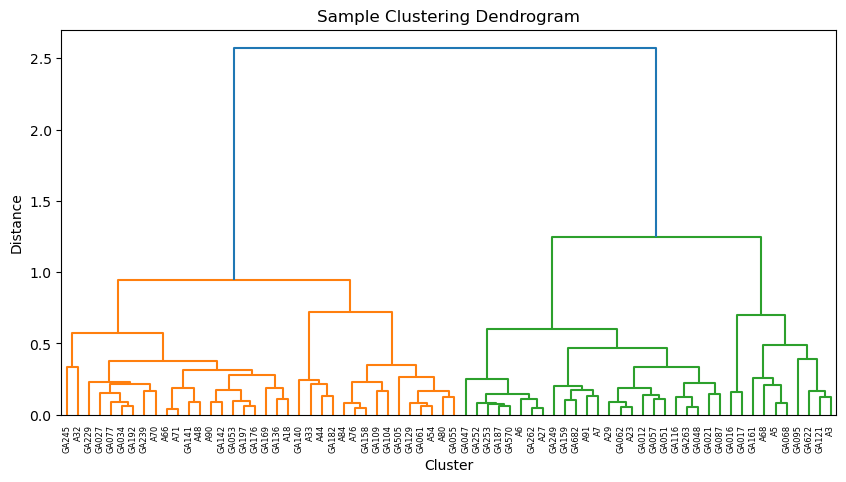

In [102]:
mean_linkage = linkage(cluster_means, method='ward')
# clustering result visualization
plt.figure(figsize=(10, 5))
dendrogram(mean_linkage, labels=cluster_means.index)
plt.title("Sample Clustering Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

#plt.savefig("../output/sample_clustering_dendrogram_first_comp1.pdf", format="pdf")
#plt.savefig("../output/sample_clustering_dendrogram_first_comp1.png", dpi=300)

In [104]:
cluster_means

,Cluster_1,Cluster_2,Cluster_3,Cluster_4
GA061,6.155506,20.345397,10.228420,15.998141
GA109,6.146564,20.258736,10.164897,15.832246
A80,6.169965,20.421899,10.316279,16.027665
GA016,5.468292,20.395387,9.915820,16.108192
A91,5.779190,20.475328,10.005206,16.040483
...,...,...,...,...
A18,6.083704,20.403208,10.038074,16.088057
GA169,5.960022,20.310985,10.050062,16.003729
A27,5.850758,20.394078,10.151989,16.053621
GA176,5.993011,20.426504,10.153977,16.011769


In [106]:
cluster_means['group'] = group_info
cluster_means

,Cluster_1,Cluster_2,Cluster_3,Cluster_4,group
GA061,6.155506,20.345397,10.228420,15.998141,Restrictive
GA109,6.146564,20.258736,10.164897,15.832246,Severe
A80,6.169965,20.421899,10.316279,16.027665,Severe
GA016,5.468292,20.395387,9.915820,16.108192,Normal
A91,5.779190,20.475328,10.005206,16.040483,Normal
...,...,...,...,...,...
A18,6.083704,20.403208,10.038074,16.088057,Obstructive
GA169,5.960022,20.310985,10.050062,16.003729,Obstructive
A27,5.850758,20.394078,10.151989,16.053621,Restrictive
GA176,5.993011,20.426504,10.153977,16.011769,Normal


In [108]:
mean_distance = pdist(cluster_means.drop('group', axis=1), metric='euclidean')
mean_linkages = linkage(mean_distance, method='ward')

In [110]:
group_colors = {'Severe':'#1F0802', 'Restrictive':'#1C646D', 'Obstructive':'#A0CD60', 'Normal':'#38184C'}
sample_color = [group_colors[group] for group in cluster_means['group']]

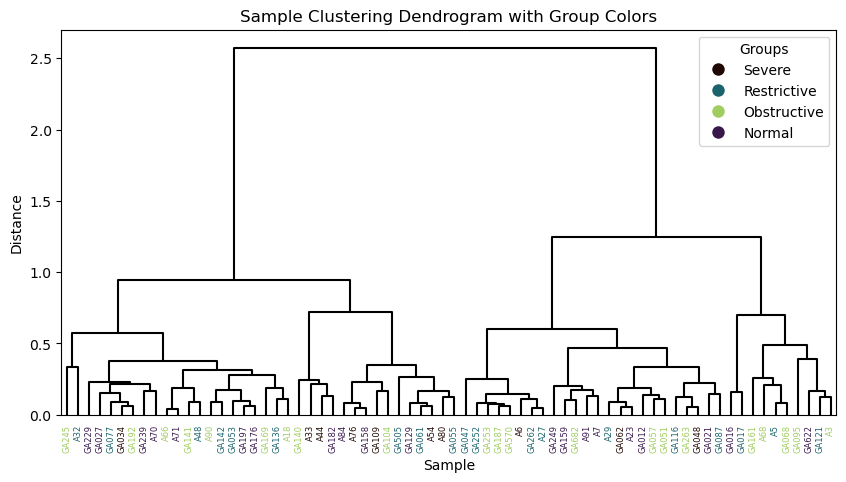

In [112]:
plt.figure(figsize=(10, 5))

dendro = dendrogram(mean_linkages, labels=cluster_means.index, 
                    link_color_func=lambda k: 'black', 
                    above_threshold_color='black',
                    color_threshold=0)

legend_labels = [plt.Line2D([0], [0], marker='o', color='w', label=key, 
                            markersize=10, markerfacecolor=color) 
                 for key, color in group_colors.items()]

# text color change (for each sample)
ax = plt.gca()
x_labels = ax.get_xmajorticklabels()
for lbl in x_labels:
    lbl.set_color(group_colors[cluster_means.loc[lbl.get_text(), 'group']])
plt.title("Sample Clustering Dendrogram with Group Colors")
plt.xlabel("Sample")
plt.ylabel("Distance")
plt.legend(handles=legend_labels, title='Groups', loc='upper right')
plt.show()
#plt.savefig("../output/sample_clustering_dendrogram_w-groups_first_comp1.pdf", format="pdf")
#plt.savefig("../output/sample_clustering_dendrogram_w-groups_first_comp1.png", dpi=300)

In [122]:
mean_fdata = pd.DataFrame(mean_linkages, columns=["idx1", "idx2", "dist", "count"])
mean_fdata.to_csv("../output/multiomics_F-exposed_dendrogram.csv")

In [124]:
cluster_means.T

,GA061,GA109,A80,GA016,A91,GA055,GA161,GA104,A76,GA121,...,GA068,GA087,A84,GA048,GA570,A18,GA169,A27,GA176,A32
Cluster_1,6.155506,6.146564,6.169965,5.468292,5.77919,6.178351,5.648646,6.272258,6.09055,5.833142,...,5.681404,5.656959,6.15495,5.754398,5.815354,6.083704,5.960022,5.850758,5.993011,6.2132
Cluster_2,20.345397,20.258736,20.421899,20.395387,20.475328,20.320202,20.301601,20.339082,20.309283,20.355728,...,20.367945,20.313906,20.308215,20.363295,20.408338,20.403208,20.310985,20.394078,20.426504,20.466514
Cluster_3,10.22842,10.164897,10.316279,9.91582,10.005206,10.366363,9.850963,10.186884,10.279435,9.75651,...,9.621021,9.986146,10.243996,9.994136,10.1255,10.038074,10.050062,10.151989,10.153977,9.979818
Cluster_4,15.998141,15.832246,16.027665,16.108192,16.040483,15.980857,15.979681,15.90117,15.948641,15.981431,...,15.941896,15.881483,15.934947,15.922812,16.00206,16.088057,16.003729,16.053621,16.011769,16.256151
group,Restrictive,Severe,Severe,Normal,Normal,Restrictive,Obstructive,Obstructive,Severe,Restrictive,...,Obstructive,Restrictive,Normal,Severe,Obstructive,Obstructive,Obstructive,Restrictive,Normal,Restrictive


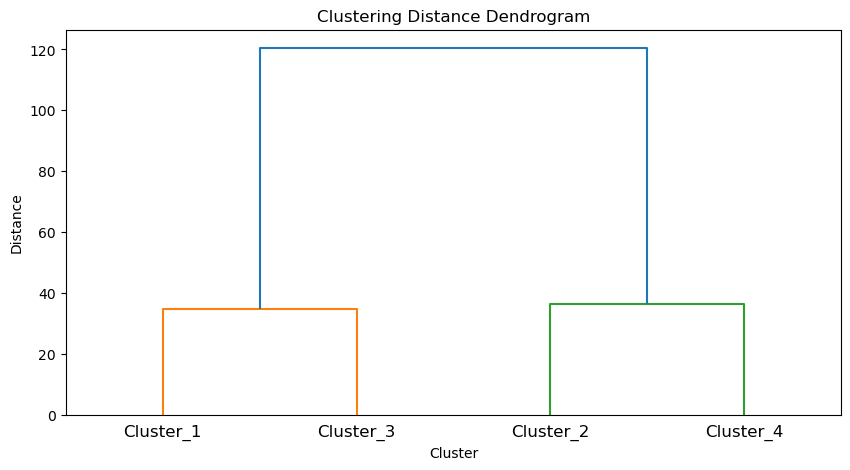

In [126]:
# visualize clustering results
plt.figure(figsize=(10, 5))
dendrogram(sample_linkage, labels=cluster_means.drop('group', axis=1).columns)
plt.title("Clustering Distance Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()
#plt.savefig("../output/clustering_distance_dendrogram_first_comp1.pdf", format='pdf')
#plt.savefig("../output/clustering_distance_dendrogram_first_comp1.png", dpi=300)

In [128]:
# 6. visualize the relationship between the Sample (PCA)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_means.drop('group', axis=1).T)

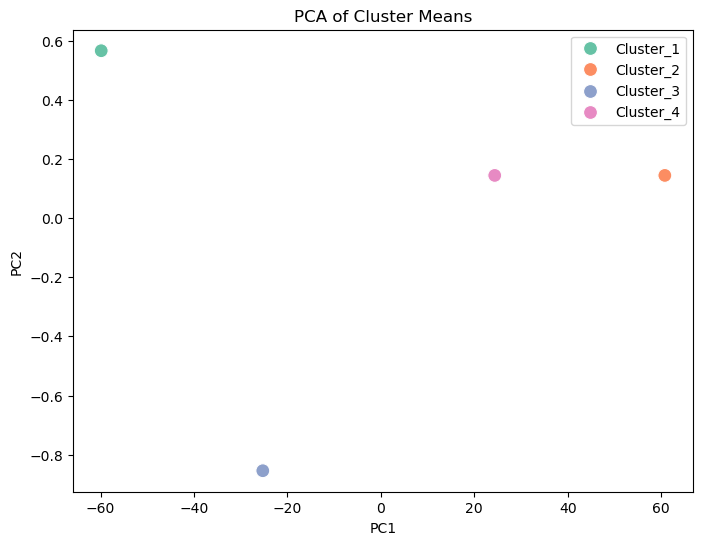

In [130]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], 
                hue=[f'Cluster_{i+1}' for i in range(k)], 
                palette='Set2', s=100)
plt.title('PCA of Cluster Means')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()
#plt.savefig("../output/pca_cluster_rank4_first_comp1.pdf", format='pdf')
#plt.savefig("../output/pca_cluster_rank4_first_comp1.png", dpi=300)

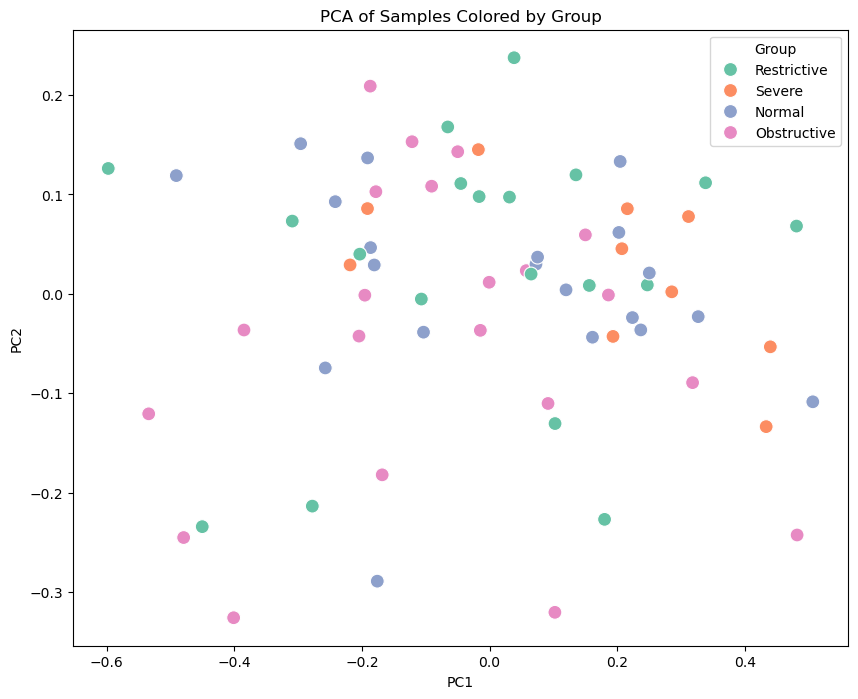

In [132]:
# 1. PCA (for each sample)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_means.drop('group', axis=1))

# 2. Transform the dataframe to PCA results
pca_df = pd.DataFrame(pca_result, index=cluster_means.index, columns=['PC1', 'PC2'])

# 3. add group information
pca_df['group'] = cluster_means['group']

# 4. PCA visualization (color by group)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='group', data=pca_df, palette='Set2', s=100)
plt.title('PCA of Samples Colored by Group')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Group')
plt.show()
#plt.savefig("../output/pca_group_rank4_first_comp1.pdf", format='pdf')
#plt.savefig("../output/pca_group_rank4_first_comp1.png", dpi=300)

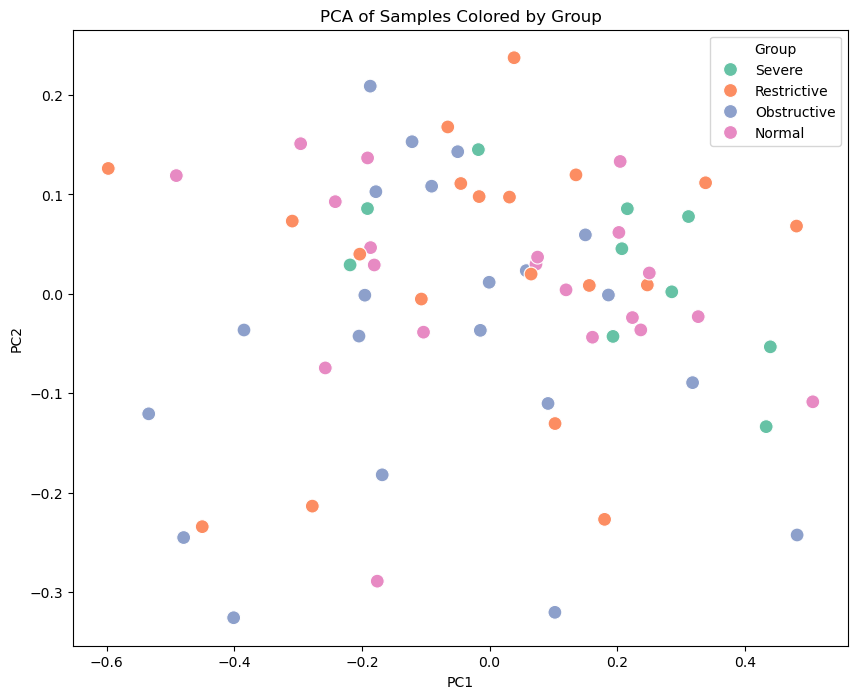

In [144]:
# test (order alignment)
# 1. PCA (for each sample)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_means.drop('group', axis=1))

# 2. Transform the dataframe to PCA results
pca_df = pd.DataFrame(pca_result, index=cluster_means.index, columns=['PC1', 'PC2'])

# 3. add group information
desired_order = ['Severe', 'Restrictive', 'Obstructive', 'Normal']
pca_df['group'] = pd.Categorical(cluster_means['group'], categories=desired_order, ordered=True)

# 4. PCA visualization (color by group)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='group', data=pca_df, palette='Set2', s=100)
plt.title('PCA of Samples Colored by Group')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Group')
plt.show()
#plt.savefig("../output/pca_group_rank4-ordered_first_comp1.pdf", format='pdf')
#plt.savefig("../output/pca_group_rank4-ordered_first_comp1.png", dpi=300)

In [146]:
pca_df.to_csv("../output/multiomics_F-exposed_pca.csv")

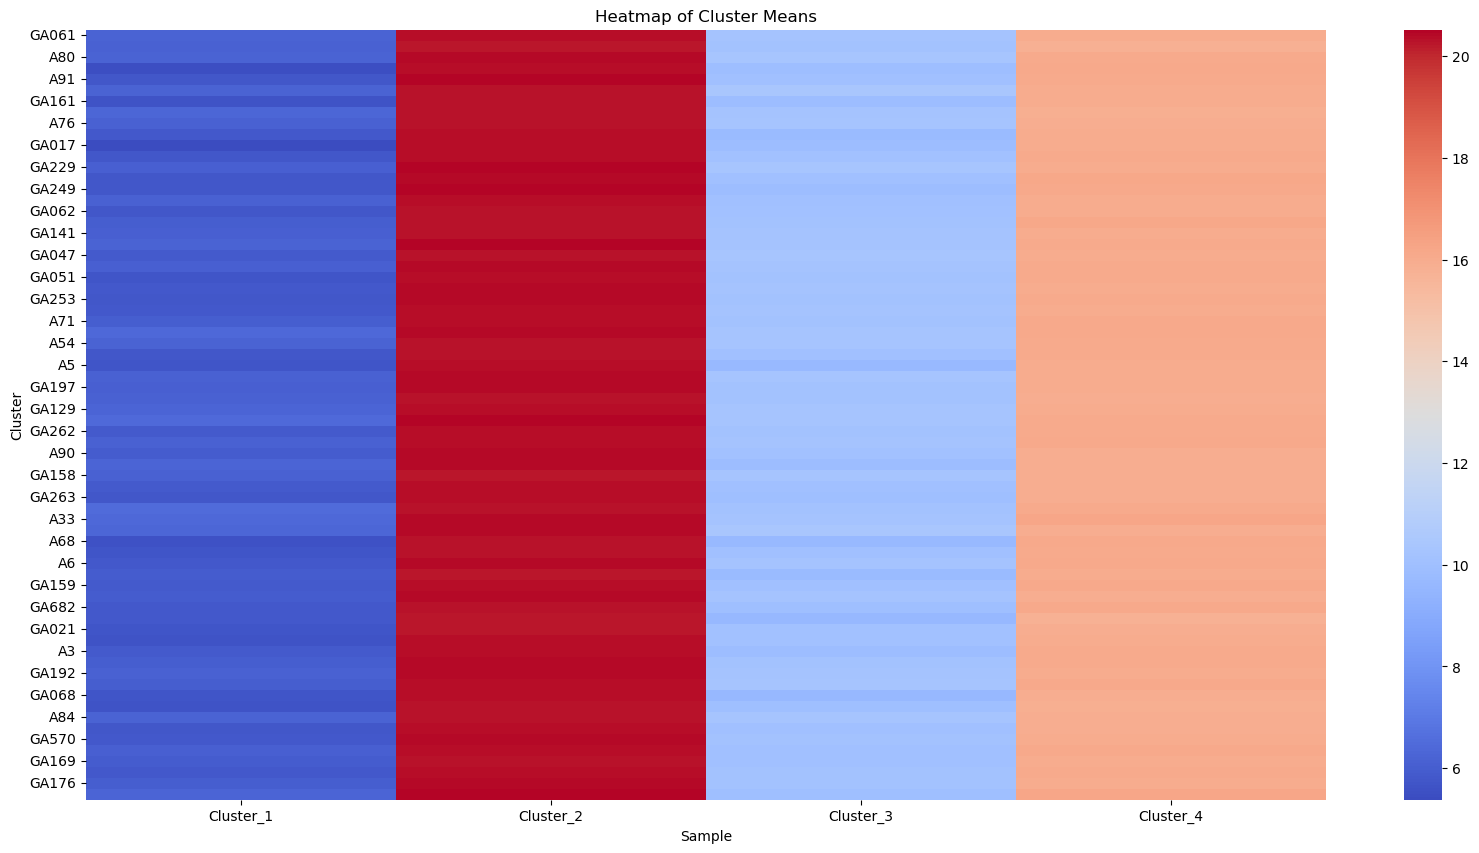

In [148]:
# 7. visualize heatmap of average value by cluster
plt.figure(figsize=(20, 10))
sns.heatmap(cluster_means.drop('group',axis=1), annot=False, cmap='coolwarm', cbar=True)
plt.title('Heatmap of Cluster Means')
plt.xlabel('Sample')
plt.ylabel('Cluster')
plt.show()
#plt.savefig("../output/heatmap_cluster_means_by-sample_first_comp1.pdf", format='pdf')
#plt.savefig("../output/heatmap_cluster_means_by-sample_first_comp1.png", dpi=300)

In [158]:
# loading
sample_info = pd.read_csv("../input/Last_all_information.csv")
data = pd.read_csv("../input/multiomics_L-exposed_log2_norm.csv", index_col=0, low_memory=False) 

# matching to label with sample information
group_info = data.columns.to_series().map(
    sample_info.set_index('Label')['Group']
)

g_data = pd.concat(
    [pd.DataFrame([group_info.values], columns=data.columns, index=["group"]), data]
)

print(g_data.head())

g_data.to_csv("../input/multiomics_L-exposed_group_log2_norm.csv")

             GA738     GA733     NA250     NA033     NA055     NA327  \
group       Group1    Group1    Group2    Group2    Group3    Group1   
16657436  3.073944  2.770339  3.034492  2.880629   2.82877  3.057892   
16657440  2.414955  2.486673  2.479409  2.553262  2.454973  2.511218   
16657445  2.074296  1.709185   2.14241  2.145889   2.33351   2.05463   
16657450    3.4852   3.46433  3.542269  3.531612  3.455609   3.49798   

             NA047     NA268     NA237     NA125  ...     NA161     NA059  \
group       Group4    Group3    Group2    Group2  ...    Group4    Group3   
16657436  3.085977  3.090339  2.993865  3.043792  ...   2.99985  3.223127   
16657440  2.448531  2.426026   2.47481  2.500093  ...  2.584421  2.457308   
16657445  2.125334  1.932046  2.103582  1.837301  ...  2.095928  1.766362   
16657450  3.480634  3.501073  3.486997  3.519013  ...  3.515316  3.390823   

             NA147     GA877     GA878     NA039     GA828     GA859  \
group       Group3    Group3    

In [160]:
# last_data
omics = pd.read_csv("../input/multiomics_L-exposed_log2_norm.csv", low_memory=False)
omics = pd.DataFrame(omics)

omics.index = omics['Unnamed: 0']
omics = omics.drop('Unnamed: 0', axis=1)
#omics

In [162]:
omics2 = pd.read_csv("../input/multiomics_L-exposed_group_log2_norm.csv", low_memory=False)
omics2 = pd.DataFrame(omics2)

omics2.index = omics2['Unnamed: 0']
omics2 = omics2.drop('Unnamed: 0', axis=1)
#omics2

In [164]:
group_info = omics2.loc['group']
group_info = group_info.T
group_info

GA738         Severe
GA733         Severe
NA250    Restrictive
NA033    Restrictive
NA055    Obstructive
            ...     
NA039    Restrictive
GA828         Normal
GA859         Normal
NA151    Obstructive
NA109    Restrictive
Name: group, Length: 69, dtype: object

In [166]:
print(omics.dtypes)

GA738    float64
GA733    float64
NA250    float64
NA033    float64
NA055    float64
          ...   
NA039    float64
GA828    float64
GA859    float64
NA151    float64
NA109    float64
Length: 69, dtype: object


In [168]:
np.random.seed(220)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42).fit(omics)
feature_clusters = kmeans.labels_

In [170]:
# add cluster informatation to the dataframe
feature_cluster_df = pd.DataFrame({'Feature': omics.index, 'Cluster': feature_clusters})

# 3. Calculate average value of the sample by cluster
cluster_means = pd.DataFrame()

for i in range(k):
    cluster_features = omics.index[feature_clusters == i]
    cluster_mean = omics.loc[cluster_features].mean(axis=0)
    cluster_means = pd.concat([cluster_means, cluster_mean], axis=1)

In [172]:
# transform the dataframe of cluster average value
cluster_means.columns = [f'Cluster_{i+1}' for i in range(k)]
cluster_means.index = omics.columns

# 4. Calculate distance between Samples (Euclidean distances)
sample_distances = pdist(cluster_means.T, metric='euclidean')

# 5. Sample Clustering (Hierarchical clustering)
sample_linkage = linkage(sample_distances, method='ward')

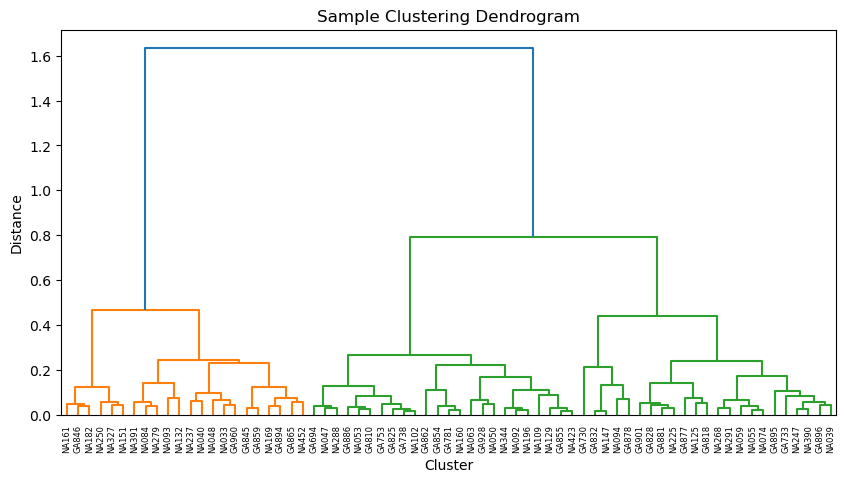

In [174]:
mean_linkage = linkage(cluster_means, method='ward')
# visualize the clustering result
plt.figure(figsize=(10, 5))
dendrogram(mean_linkage, labels=cluster_means.index)
plt.title("Sample Clustering Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

#plt.savefig("../output/sample_clustering_dendrogram_last_comp1.pdf", format="pdf")
#plt.savefig("../output/sample_clustering_dendrogram_last_comp1.png", dpi=300)

In [176]:
cluster_means

,Cluster_1,Cluster_2,Cluster_3,Cluster_4
GA738,2.634215,17.856332,1.839997,7.850583
GA733,2.628804,17.911741,1.849662,7.757227
NA250,2.629763,17.805848,1.833006,8.184184
NA033,2.629900,17.915741,1.827219,8.066444
NA055,2.631810,17.789051,1.838919,7.798694
...,...,...,...,...
NA039,2.631397,17.865657,1.832022,7.778053
GA828,2.636539,17.844188,1.789901,7.721314
GA859,2.640308,17.859937,1.788717,8.071015
NA151,2.640992,17.792192,1.806076,8.229445


In [178]:
cluster_means['group'] = group_info
cluster_means

,Cluster_1,Cluster_2,Cluster_3,Cluster_4,group
GA738,2.634215,17.856332,1.839997,7.850583,Severe
GA733,2.628804,17.911741,1.849662,7.757227,Severe
NA250,2.629763,17.805848,1.833006,8.184184,Restrictive
NA033,2.629900,17.915741,1.827219,8.066444,Restrictive
NA055,2.631810,17.789051,1.838919,7.798694,Obstructive
...,...,...,...,...,...
NA039,2.631397,17.865657,1.832022,7.778053,Restrictive
GA828,2.636539,17.844188,1.789901,7.721314,Normal
GA859,2.640308,17.859937,1.788717,8.071015,Normal
NA151,2.640992,17.792192,1.806076,8.229445,Obstructive


In [180]:
mean_distance = pdist(cluster_means.drop('group', axis=1), metric='euclidean')
mean_linkages = linkage(mean_distance, method='ward')

In [182]:
group_colors = {'Severe':'#1F0802', 'Restrictive':'#1C646D', 'Obstructive':'#A0CD60', 'Normal':'#38184C'}
sample_color = [group_colors[group] for group in cluster_means['group']]

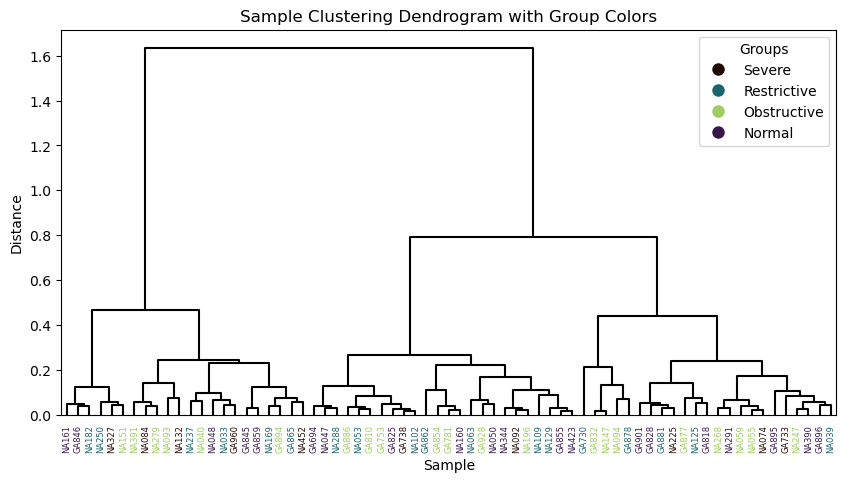

In [184]:
plt.figure(figsize=(10, 5))

dendro = dendrogram(mean_linkages, labels=cluster_means.index, 
                    link_color_func=lambda k: 'black', 
                    above_threshold_color='black',
                    color_threshold=0)

legend_labels = [plt.Line2D([0], [0], marker='o', color='w', label=key, 
                            markersize=10, markerfacecolor=color) 
                 for key, color in group_colors.items()]

# text color change for each sample
ax = plt.gca()
x_labels = ax.get_xmajorticklabels()
for lbl in x_labels:
    lbl.set_color(group_colors[cluster_means.loc[lbl.get_text(), 'group']])
plt.title("Sample Clustering Dendrogram with Group Colors")
plt.xlabel("Sample")
plt.ylabel("Distance")
plt.legend(handles=legend_labels, title='Groups', loc='upper right')
plt.show()
#plt.savefig("../output/sample_clustering_dendrogram_w-groups_last_comp1.pdf", format="pdf")
#plt.savefig("../output/sample_clustering_dendrogram_w-groups_last_comp1.png", dpi=300)

In [186]:
mean_ldata = pd.DataFrame(mean_linkages, columns=["idx1", "idx2", "dist", "count"])
mean_ldata.to_csv("../output/multiomics_L-exposed_dendrogram.csv")

In [188]:
cluster_means.T

,GA738,GA733,NA250,NA033,NA055,NA327,NA047,NA268,NA237,NA125,...,NA161,NA059,NA147,GA877,GA878,NA039,GA828,GA859,NA151,NA109
Cluster_1,2.634215,2.628804,2.629763,2.6299,2.63181,2.637211,2.632933,2.620236,2.640286,2.65256,...,2.656669,2.627869,2.645964,2.644578,2.640828,2.631397,2.636539,2.640308,2.640992,2.633112
Cluster_2,17.856332,17.911741,17.805848,17.915741,17.789051,17.820086,17.893458,17.799099,17.941017,17.846329,...,17.851776,17.763735,17.799463,17.805542,17.777181,17.865657,17.844188,17.859937,17.792192,17.749847
Cluster_3,1.839997,1.849662,1.833006,1.827219,1.838919,1.836024,1.797049,1.874732,1.792694,1.757861,...,1.757262,1.848557,1.773513,1.783675,1.782878,1.832022,1.789901,1.788717,1.806076,1.813443
Cluster_4,7.850583,7.757227,8.184184,8.066444,7.798694,8.230573,7.829786,7.756954,8.024459,7.786791,...,8.251376,7.781837,7.612721,7.76949,7.694197,7.778053,7.721314,8.071015,8.229445,7.874322
group,Severe,Severe,Restrictive,Restrictive,Obstructive,Severe,Normal,Obstructive,Restrictive,Restrictive,...,Normal,Obstructive,Obstructive,Obstructive,Restrictive,Restrictive,Normal,Normal,Obstructive,Restrictive


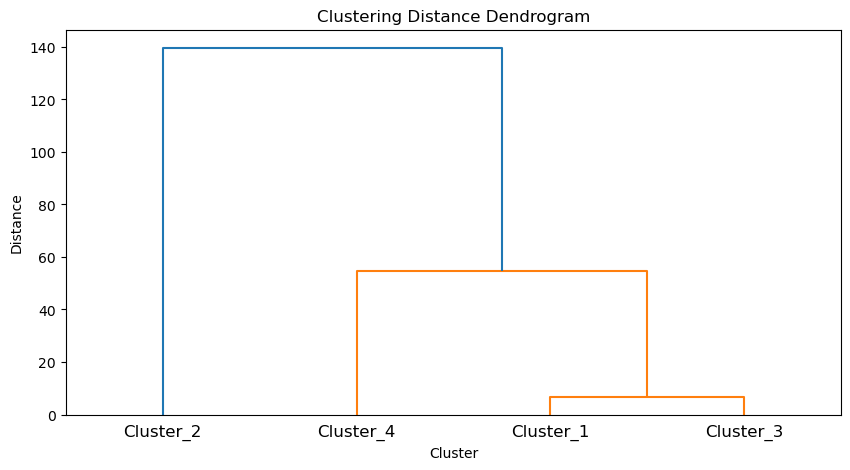

In [190]:
# visualize clustering result
plt.figure(figsize=(10, 5))
dendrogram(sample_linkage, labels=cluster_means.drop('group', axis=1).columns)
plt.title("Clustering Distance Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()
#plt.savefig("../output/clustering_distance_dendrogram_last_comp1.pdf", format='pdf')
#plt.savefig("../output/clustering_distance_dendrogram_last_comp1.png", dpi=300)

In [192]:
# 6. Visualize the relationship between the sample (PCA)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_means.drop('group', axis=1).T)

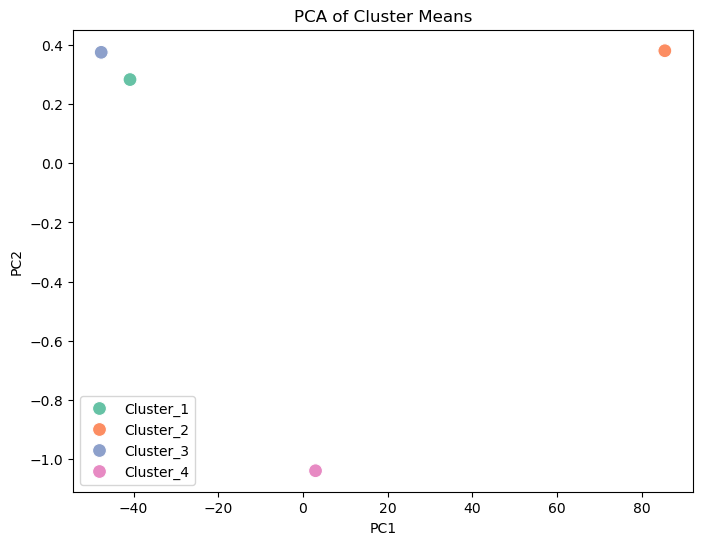

In [194]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], 
                hue=[f'Cluster_{i+1}' for i in range(k)], 
                palette='Set2', s=100)
plt.title('PCA of Cluster Means')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()
#plt.savefig("../output/pca_cluster_rank4_last_comp1.pdf", format='pdf')
#plt.savefig("../output/pca_cluster_rank4_last_comp1.png", dpi=300)

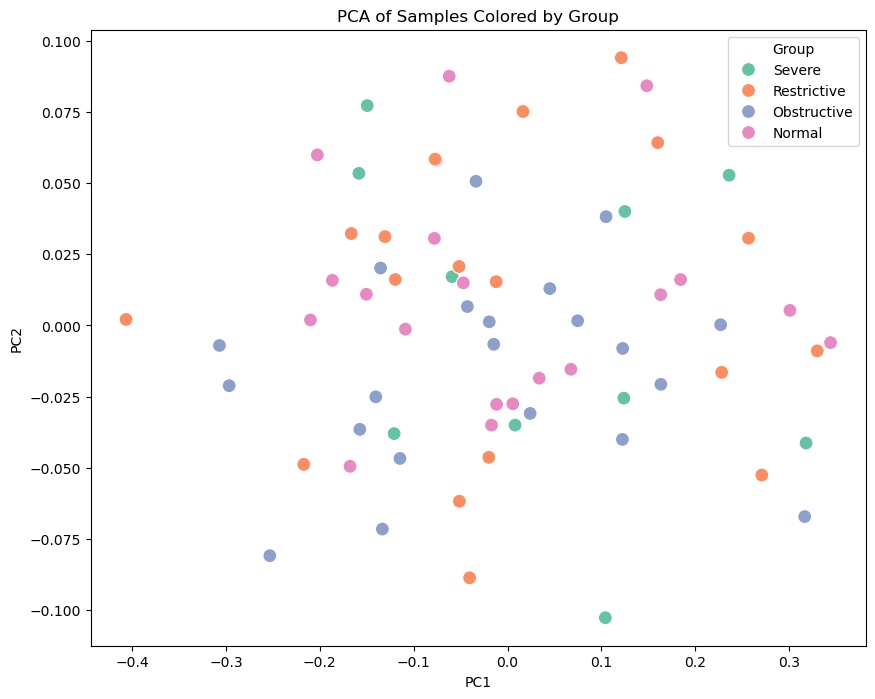

In [196]:
# 1. PCA 
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_means.drop('group', axis=1))

# 2. transform result to dataframe
pca_df = pd.DataFrame(pca_result, index=cluster_means.index, columns=['PC1', 'PC2'])

# 3. add group information
pca_df['group'] = cluster_means['group']

# 4. PCA visualization (color by groups)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='group', data=pca_df, palette='Set2', s=100)
plt.title('PCA of Samples Colored by Group')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Group')
plt.show()
#plt.savefig("../output/pca_group_rank4_last_comp1.pdf", format='pdf')
#plt.savefig("../output/pca_group_rank4_last_comp1.png", dpi=300)

In [198]:
pca_df.to_csv("../output/multiomics_L-exposed_pca.csv")

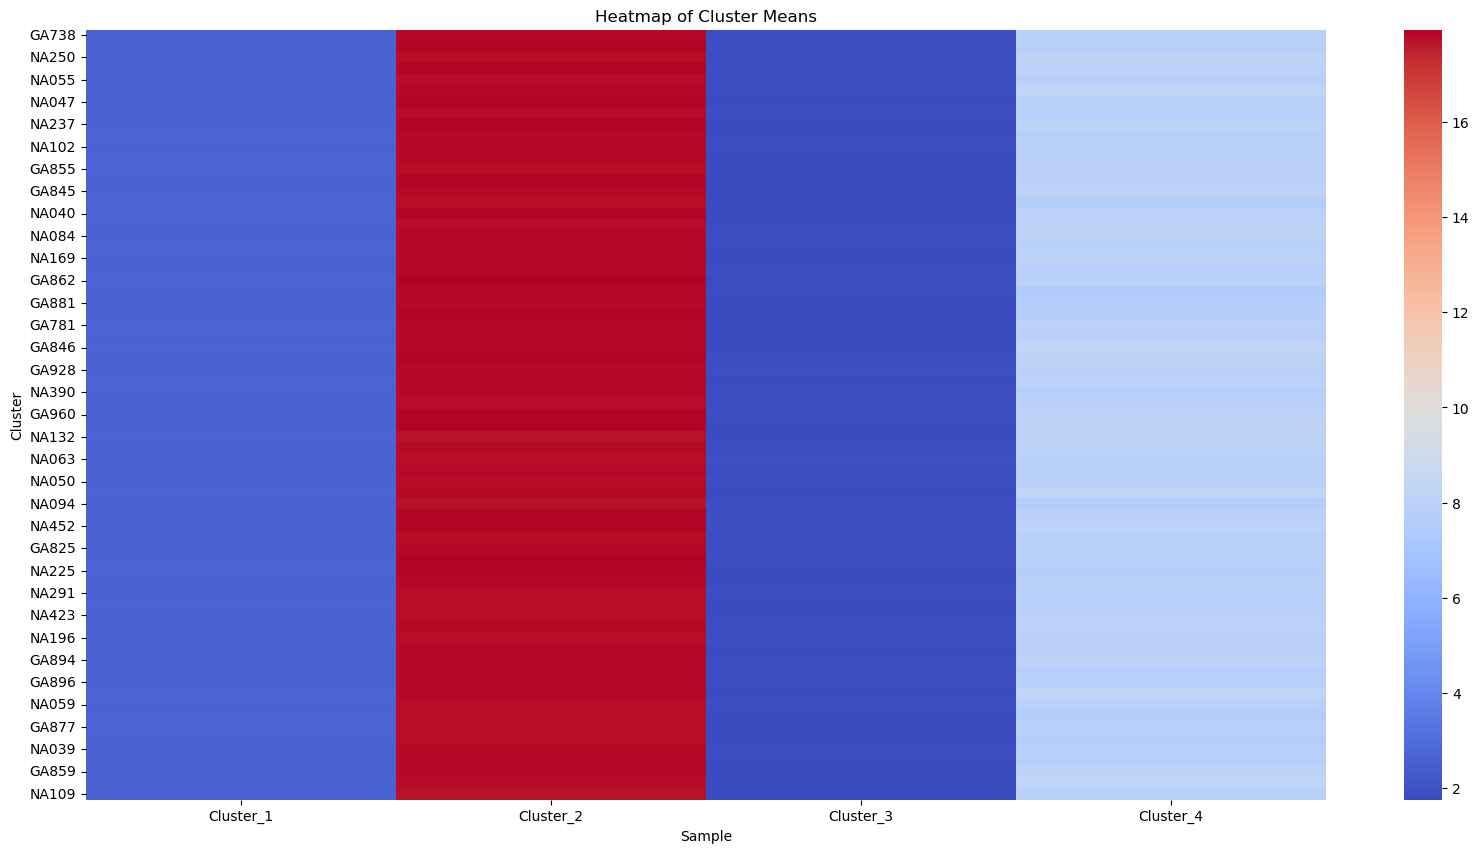

In [200]:
plt.figure(figsize=(20, 10))
sns.heatmap(cluster_means.drop('group',axis=1), annot=False, cmap='coolwarm', cbar=True)
plt.title('Heatmap of Cluster Means')
plt.xlabel('Sample')
plt.ylabel('Cluster')
plt.show()
#plt.savefig("../output/heatmap_cluster_means_by-sample_last_comp1.pdf", format='pdf')
#plt.savefig("../output/heatmap_cluster_means_by-sample_last_comp1.png", dpi=300)